# 3.5 Manual Obstacle Labeling

Clusters the point cloud with DBSCAN, then lets you hand-label each cluster.

Can run on either a **raw** LAZ or a **BGT-labeled** LAZ (output of step 2.5). When using
the labeled cloud, existing BGT labels are shown as coloured rings on top of the RGB points
and can be confirmed with one click.

**Dependencies:**
- `data/input/pointcloud/raw/<tilecode>.laz` — raw LiDAR (USE_BGT_LABELED=False)
- `data/output/labeled_pointcloud/bgt_labeled_<tilecode>.laz` — BGT-labeled cloud (USE_BGT_LABELED=True)
- `data/output/ahn/ahn_<tilecode>.npz` — ground elevation grid

**Output:** `data/output/obstacles/obstacles_labeled_<tilecode>.csv` + `.geojson` + splits JSON

In [21]:
from pathlib import Path

TILECODE = "120300_489300"

# Set True to load the BGT-labeled cloud (after step 2.5) — existing labels shown as overlay.
# Set False to use the raw LiDAR directly.
USE_BGT_LABELED = True

if USE_BGT_LABELED:
    # INPUT_LAZ = Path(f"data/output/labeled_pointcloud/bgt_labeled_{TILECODE}.laz")
    INPUT_LAZ = Path(f"/Users/minkeverweij/UPSW_neo/data/output/labeled_pointcloud/bgt_labeled_{TILECODE}.laz")
else:
    INPUT_LAZ = Path(f"data/input/pointcloud/raw/{TILECODE}.laz")

AHN_NPZ = Path(f"data/output/ahn/ahn_{TILECODE}.npz")
OUT_DIR  = Path("data/output/obstacles")
OUT_DIR.mkdir(parents=True, exist_ok=True)

H_MIN = 0.3; H_MAX = 5.0
VOXEL = 0.2; EPS = 0.5; MIN_VOXELS = 5; MIN_PTS = 10
MIN_AREA = 0.1; MAX_AREA = 40.0
PC_PADDING = 0.15

# Manual label categories  (code, display name, hex colour)
LABEL_SET = [
    (40,  'Car',           '#d62728'),
    (44,  'Single bike',   '#aec7e8'),
    (46,  'Multi-bike',    '#1f77b4'),
    (47,  'Bike on pole',  '#17becf'),
    (45,  'Scooter',       '#ff9896'),
    (83,  'Container',     '#8c564b'),
    (81,  'Rubbish bin',   '#9467bd'),
    (99,  'Noise',         '#444444'),
]

# Colours for the existing BGT label overlay
BGT_COLORS = {
    1:  '#f5f500',  # Road
    9:  '#99cc99',  # Ground
    10: '#ff8800',  # Building
    30: '#2ca02c',  # Tree
    40: '#d62728',  # Car
    60: '#ff7f0e',  # Streetlight
    65: '#7f7f7f',  # Bollard
    70: '#aaaaaa',  # Tram cable
    79: '#cccccc',  # Cable
    83: '#8c564b',  # Container
    99: '#333333',  # Noise
}

In [22]:
import numpy as np
import laspy
from sklearn.cluster import DBSCAN
from scipy.spatial import cKDTree
from shapely.geometry import MultiPoint

# ── 1. Load point cloud ───────────────────────────────────────────────────────
print(f"Loading {'BGT-labeled' if USE_BGT_LABELED else 'raw'} cloud …", end=" ", flush=True)
pc  = laspy.read(str(INPUT_LAZ))
xyz = np.column_stack([np.asarray(pc.x), np.asarray(pc.y), np.asarray(pc.z)]).astype(np.float32)
rgb = np.column_stack([
    np.asarray(pc.red,   dtype=np.float32),
    np.asarray(pc.green, dtype=np.float32),
    np.asarray(pc.blue,  dtype=np.float32),
]) / 65280.0

if 'label' in pc.point_format.extra_dimension_names:
    point_labels = np.asarray(pc.label, dtype=np.int32)
else:
    point_labels = np.zeros(len(xyz), dtype=np.int32)
print(f"{len(xyz):,} points")

# ── 2. Height above ground ────────────────────────────────────────────────────
print("Computing heights above ground …", end=" ", flush=True)
ahn    = np.load(str(AHN_NPZ))
x_arr  = ahn['x'].astype(np.float32)
y_arr  = ahn['y'].astype(np.float32)
ground = ahn['ground'].astype(np.float32)
res    = float(x_arr[1] - x_arr[0])
x0     = float(x_arr[0]); y_top = float(y_arr[0])

col_idx = np.clip(((xyz[:, 0] - x0)   / res).astype(np.int32), 0, ground.shape[1] - 1)
row_idx = np.clip(((y_top - xyz[:, 1]) / res).astype(np.int32), 0, ground.shape[0] - 1)
gz      = ground[row_idx, col_idx]
height  = xyz[:, 2] - gz

obs_mask     = (height > H_MIN) & (height < H_MAX) & np.isfinite(height)
xyz_obs      = xyz[obs_mask]
rgb_obs      = rgb[obs_mask]
ex_labels_obs = point_labels[obs_mask]
print(f"{obs_mask.sum():,} obstacle candidates")

# ── 3. Voxel downsample + DBSCAN ─────────────────────────────────────────────
print("Running DBSCAN …", end=" ", flush=True)
vox_ij = np.floor(xyz_obs[:, :2] / VOXEL).astype(np.int64)
_, uniq = np.unique(vox_ij, axis=0, return_index=True)
xyz_vox = xyz_obs[uniq]

db = DBSCAN(eps=EPS, min_samples=MIN_VOXELS, n_jobs=-1)
vox_cids = db.fit_predict(xyz_vox[:, :2])

tree = cKDTree(xyz_vox[:, :2])
_, nn = tree.query(xyz_obs[:, :2], workers=-1)
obs_cids    = vox_cids[nn]
unique_cids = np.unique(obs_cids[obs_cids >= 0])
print(f"{len(unique_cids)} raw clusters")

# ── 4. Build convex-hull polygons + dominant BGT label ────────────────────────
obstacles = []
for cid in unique_cids:
    mask = obs_cids == cid
    if mask.sum() < MIN_PTS:
        continue
    pts2d = xyz_obs[mask, :2]
    if len(pts2d) < 3:
        continue
    hull = MultiPoint(pts2d.astype(np.float64)).convex_hull
    if hull.is_empty or hull.geom_type not in ('Polygon', 'MultiPolygon'):
        continue
    area = hull.area
    if not (MIN_AREA <= area <= MAX_AREA):
        continue

    ex   = ex_labels_obs[mask]
    nz   = ex[(ex > 0) & (ex != 99)]
    if len(nz) > 0:
        vals, counts = np.unique(nz, return_counts=True)
        dom_lbl  = int(vals[counts.argmax()])
        dom_frac = float(counts.max() / len(ex))
    else:
        dom_lbl  = 0
        dom_frac = 0.0

    obstacles.append({
        'hull':           hull,
        'area':           round(area, 3),
        'pts_xy':         pts2d,
        'rgb':            rgb_obs[mask],
        'existing_label': dom_lbl,
        'existing_frac':  dom_frac,
    })

print(f"{len(obstacles)} obstacles after area filter ({MIN_AREA}–{MAX_AREA} m²)")
bgt_n = sum(1 for o in obstacles if o['existing_label'] > 0)
print(f"  {bgt_n} have an existing BGT label  |  {len(obstacles)-bgt_n} unknown")

Loading BGT-labeled cloud … 26,340,708 points
Computing heights above ground … 12,316,174 obstacle candidates
Running DBSCAN … 95 raw clusters
75 obstacles after area filter (0.1–40.0 m²)
  34 have an existing BGT label  |  41 unknown


In [23]:
import pandas as pd, json
from datetime import datetime

LABELS_CSV  = OUT_DIR / f"obstacles_labeled_{TILECODE}.csv"
SPLITS_JSON = OUT_DIR / f"obstacles_splits_{TILECODE}.json"

if LABELS_CSV.exists():
    labels_df = pd.read_csv(LABELS_CSV)
    if 'confirmed' not in labels_df.columns:
        labels_df['confirmed'] = False
    print(f"Resumed: {len(labels_df)} obstacles already labeled")
else:
    labels_df = pd.DataFrame(columns=[
        'obstacle_idx', 'tilecode', 'area', 'label_id', 'label_name', 'confirmed', 'timestamp'])
    print("Starting fresh")

labeled_ids = set(labels_df['obstacle_idx'].tolist())

if SPLITS_JSON.exists():
    with open(SPLITS_JSON) as f:
        split_map = {int(k): v for k, v in json.load(f).items()}
    print(f"  {len(split_map)} split clusters loaded")
else:
    split_map = {}

def save_label(idx, label_id, label_name, confirmed=False):
    global labels_df, labeled_ids
    row = {
        'obstacle_idx': idx, 'tilecode': TILECODE, 'area': obstacles[idx]['area'],
        'label_id': label_id, 'label_name': label_name, 'confirmed': confirmed,
        'timestamp': datetime.now().isoformat(timespec='seconds'),
    }
    labels_df = labels_df[labels_df['obstacle_idx'] != idx]
    labels_df = pd.concat([labels_df, pd.DataFrame([row])], ignore_index=True)
    labels_df.to_csv(LABELS_CSV, index=False)
    labeled_ids = set(labels_df['obstacle_idx'].tolist())

def save_splits(idx, regions):
    split_map[idx] = regions
    with open(SPLITS_JSON, 'w') as f:
        json.dump(split_map, f)

Resumed: 24 obstacles already labeled


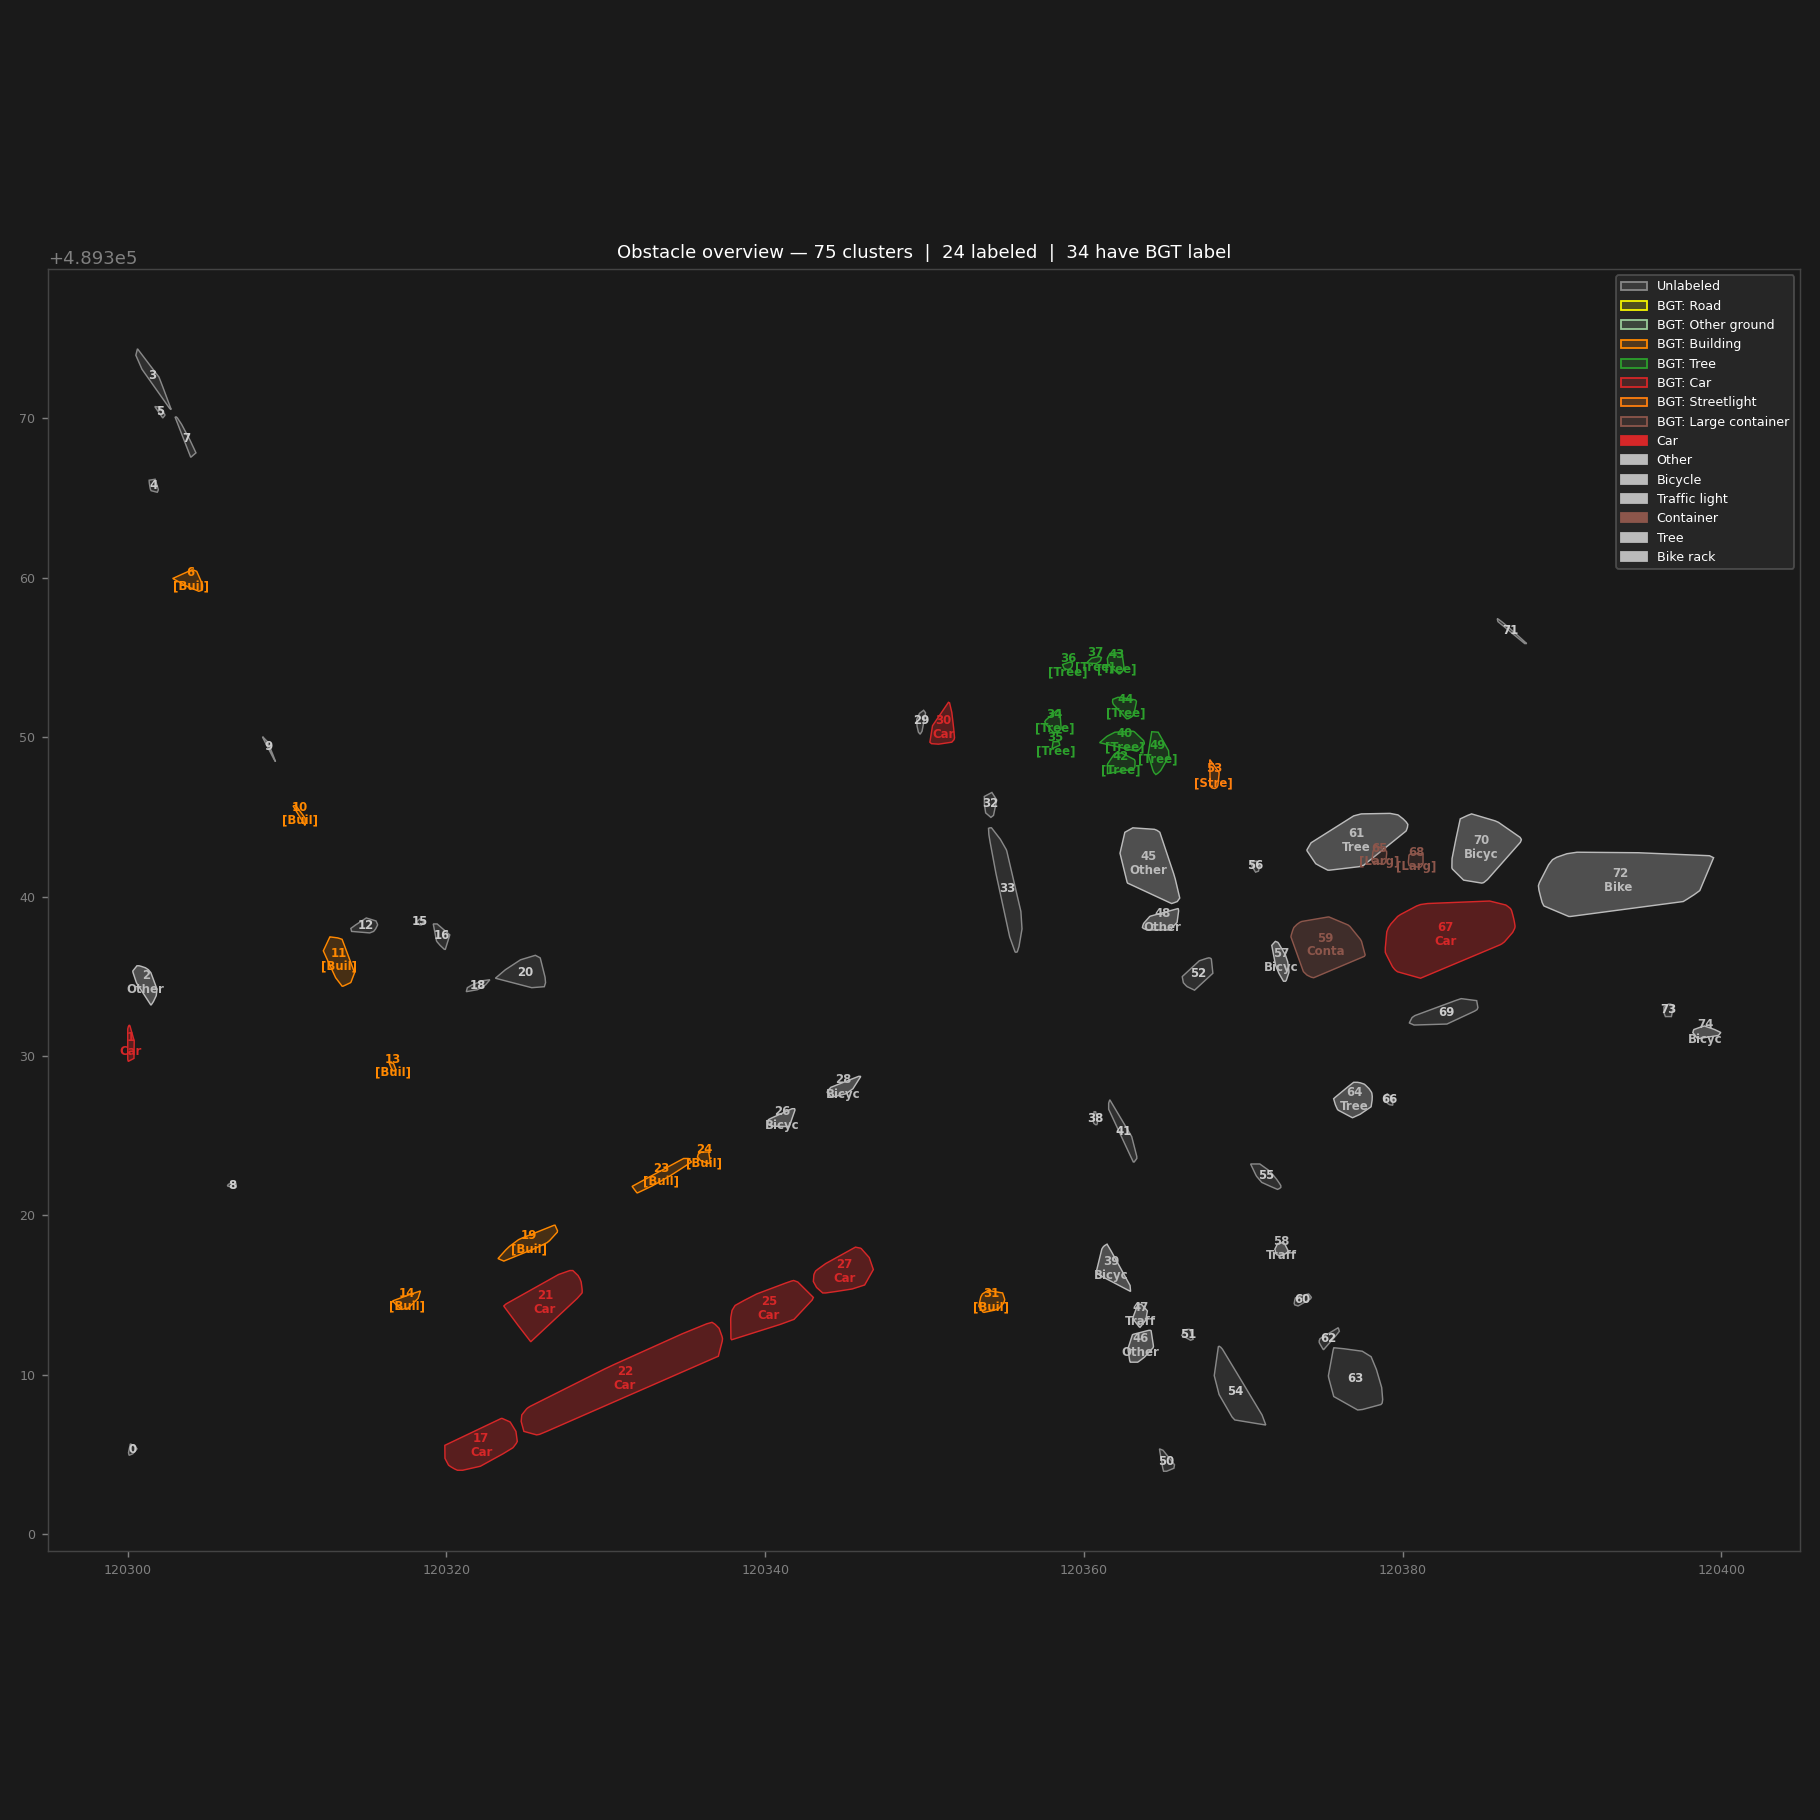

75 clusters  |  24 labeled  |  0 split  →  data/output/obstacles/overview_120300_489300.png


In [24]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from utils.labels import Labels
from IPython.display import display as ipy_display, Image as IPyImage

label_color_map = {lname: lcolor for _, lname, lcolor in LABEL_SET}
overview_path = OUT_DIR / f"overview_{TILECODE}.png"

fig, ax = plt.subplots(figsize=(14, 14))
ax.set_facecolor('#1a1a1a'); fig.patch.set_facecolor('#1a1a1a')

for i, obs in enumerate(obstacles):
    hull = obs['hull']
    ring = np.array(hull.exterior.coords)
    cx, cy = hull.centroid.x, hull.centroid.y

    if i in split_map:
        fc, ec, tc = '#ff880033', '#ff8800', '#ff8800'
        lbl_txt = f"{i}\nsplit"
    elif i in labeled_ids:
        r = labels_df[labels_df['obstacle_idx'] == i].iloc[0]
        col = label_color_map.get(r['label_name'], '#bbbbbb')
        fc, ec, tc = col + '55', col, col
        suffix = ' ✓' if r.get('confirmed') else ''
        lbl_txt = f"{i}\n{r['label_name'][:5]}{suffix}"
    elif obs['existing_label'] > 0:
        col = BGT_COLORS.get(obs['existing_label'], '#ffffff')
        lname = Labels.STR_DICT.get(obs['existing_label'], str(obs['existing_label']))
        fc, ec, tc = col + '33', col, col
        lbl_txt = f"{i}\n[{lname[:4]}]"
    else:
        fc, ec, tc = '#ffffff18', '#888888', '#cccccc'
        lbl_txt = str(i)

    ax.add_patch(plt.Polygon(ring, closed=True, facecolor=fc, edgecolor=ec, linewidth=0.8))
    ax.text(cx, cy, lbl_txt, color=tc, fontsize=6.5, ha='center', va='center',
            fontweight='bold', zorder=5)

all_x = np.concatenate([np.array(o['hull'].exterior.coords)[:, 0] for o in obstacles])
all_y = np.concatenate([np.array(o['hull'].exterior.coords)[:, 1] for o in obstacles])
pad = 5.0
ax.set_xlim(all_x.min() - pad, all_x.max() + pad)
ax.set_ylim(all_y.min() - pad, all_y.max() + pad)
ax.set_aspect('equal')
ax.set_title(
    f'Obstacle overview — {len(obstacles)} clusters  |  {len(labeled_ids)} labeled  '
    f'|  {sum(1 for o in obstacles if o["existing_label"]>0)} have BGT label',
    color='white', fontsize=10)
ax.tick_params(labelsize=7, colors='grey')
for sp in ax.spines.values(): sp.set_edgecolor('#444')

patches = [mpatches.Patch(facecolor='#ffffff18', edgecolor='#888', label='Unlabeled')]
patches += [mpatches.Patch(facecolor=BGT_COLORS.get(c,'#aaa')+'33',
                           edgecolor=BGT_COLORS.get(c,'#aaa'),
                           label=f'BGT: {Labels.STR_DICT.get(c,str(c))}')
            for c in sorted({o['existing_label'] for o in obstacles if o['existing_label']>0})]
seen = set()
for i in labeled_ids:
    r = labels_df[labels_df['obstacle_idx'] == i].iloc[0]
    n = r['label_name']
    if n not in seen:
        seen.add(n)
        patches.append(mpatches.Patch(color=label_color_map.get(n,'#bbb'), label=n))
ax.legend(handles=patches, loc='upper right', fontsize=7,
          facecolor='#2a2a2a', edgecolor='#555', labelcolor='white')

plt.tight_layout()
fig.savefig(overview_path, dpi=130, facecolor='#1a1a1a')
plt.close(fig)
ipy_display(IPyImage(str(overview_path)))
print(f"{len(obstacles)} clusters  |  {len(labeled_ids)} labeled  |  {len(split_map)} split  →  {overview_path}")

In [29]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import io
from utils.labels import Labels

label_color_map = {lname: lcolor for _, lname, lcolor in LABEL_SET}

# ── State ──────────────────────────────────────────────────────────────────────
state = {
    'idx': 0,
    'mode': 'label',        # 'label' | 'split_define' | 'split_label'
    'split_regions': [],    # [[xmin, xmax, ymin, ymax], ...]
    'split_subidx': 0,
}
for i in range(len(obstacles)):
    if i not in labeled_ids:
        state['idx'] = i; break

# ── Render helpers ─────────────────────────────────────────────────────────────
def _get_pts(idx):
    pts = obstacles[idx]['pts_xy']
    bxt0, byt0 = pts[:, 0].min(), pts[:, 1].min()
    bxt1, byt1 = pts[:, 0].max(), pts[:, 1].max()
    m = ((xyz_obs[:, 0] >= bxt0 - 0.01) & (xyz_obs[:, 0] <= bxt1 + 0.01) &
         (xyz_obs[:, 1] >= byt0 - 0.01) & (xyz_obs[:, 1] <= byt1 + 0.01))
    return xyz_obs[m], rgb_obs[m], ex_labels_obs[m], obstacles[idx]['hull'].bounds

def _sa(ax):
    ax.set_facecolor('#1a1a1a')
    for sp in ax.spines.values(): sp.set_edgecolor('#444')
    ax.tick_params(labelsize=6, colors='grey')

def _fig_png(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, facecolor='#1a1a1a')
    plt.close(fig); buf.seek(0)
    return buf.read()

def render_label_view(idx):
    obs = obstacles[idx]
    xyz_cl, rgb_cl, ex_cl, (bx0, by0, bx1, by1) = _get_pts(idx)
    pad = PC_PADDING

    fig, (ax_t, ax_s) = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor('#1a1a1a')
    _sa(ax_t); _sa(ax_s)

    # RGB points
    ax_t.scatter(xyz_cl[:, 0], xyz_cl[:, 1], c=rgb_cl, s=8, linewidths=0, zorder=2)
    # BGT label rings
    for lbl in np.unique(ex_cl):
        if lbl <= 0: continue
        m   = ex_cl == lbl
        col = BGT_COLORS.get(int(lbl), '#ffffff')
        ax_t.scatter(xyz_cl[m, 0], xyz_cl[m, 1], s=22, facecolors='none',
                     edgecolors=col, linewidths=0.8, alpha=0.6, zorder=3)
    ring = list(obs['hull'].exterior.coords)
    ax_t.add_patch(plt.Polygon(ring, closed=True, facecolor='none',
                               edgecolor='#666', linewidth=0.7, zorder=4))
    ax_t.set_aspect('equal')
    ax_t.set_xlim(bx0 - pad, bx1 + pad); ax_t.set_ylim(by0 - pad, by1 + pad)

    dom = obs.get('existing_label', 0)
    if dom > 0:
        lname = Labels.STR_DICT.get(dom, str(dom))
        frac  = obs.get('existing_frac', 0.0)
        ax_t.set_title(f'BGT: {lname}  ({frac:.0%})',
                       color=BGT_COLORS.get(dom, 'yellow'), fontsize=8)
    else:
        ax_t.set_title('Top view', color='#888', fontsize=8)

    ax_s.scatter(xyz_cl[:, 0], xyz_cl[:, 2], c=rgb_cl, s=8, linewidths=0)
    ax_s.set_xlim(bx0 - pad, bx1 + pad)
    ax_s.set_title('Side profile', color='#888', fontsize=8)
    ax_s.set_xlabel('X', color='grey', fontsize=7)
    ax_s.set_ylabel('Z', color='grey', fontsize=7)

    if idx in labeled_ids:
        r = labels_df[labels_df['obstacle_idx'] == idx].iloc[0]
        conf = '  ✓confirmed' if r.get('confirmed') else ''
        fig.suptitle(f"labeled: {r['label_name']}{conf}", color='skyblue', fontsize=9)

    plt.tight_layout(pad=0.5)
    return _fig_png(fig)

def render_split_preview(idx, regions):
    obs = obstacles[idx]
    xyz_cl, rgb_cl, _, (bx0, by0, bx1, by1) = _get_pts(idx)
    pad = PC_PADDING * 3
    clrs = ['#ffff00', '#00ff88', '#ff8800', '#ff44ff']

    fig, ax = plt.subplots(figsize=(7, 7))
    fig.patch.set_facecolor('#1a1a1a'); _sa(ax)
    ax.scatter(xyz_cl[:, 0], xyz_cl[:, 1], c=rgb_cl, s=8, linewidths=0, zorder=2)
    ring = list(obs['hull'].exterior.coords)
    ax.add_patch(plt.Polygon(ring, closed=True, facecolor='none',
                             edgecolor='#555', linewidth=0.7, zorder=3))
    for i, r in enumerate(regions):
        xmn, xmx, ymn, ymx = r
        col = clrs[i % len(clrs)]
        ax.add_patch(plt.Rectangle((xmn, ymn), xmx - xmn, ymx - ymn,
                                   facecolor=col, alpha=0.2, edgecolor=col,
                                   linewidth=1.5, zorder=4))
        ax.text((xmn+xmx)/2, (ymn+ymx)/2, str(i+1),
                color=col, fontsize=14, fontweight='bold', ha='center', va='center', zorder=5)
    ax.set_aspect('equal')
    ax.set_xlim(bx0 - pad, bx1 + pad); ax.set_ylim(by0 - pad, by1 + pad)
    ax.set_title(f'Split preview — cluster #{idx}  ({len(regions)} regions)', color='white', fontsize=10)
    plt.tight_layout()
    return _fig_png(fig)

def render_subregion(idx, si, regions):
    obs = obstacles[idx]
    xyz_cl, rgb_cl, _, (bx0, by0, bx1, by1) = _get_pts(idx)
    pad = PC_PADDING * 2
    xmn, xmx, ymn, ymx = regions[si]
    in_r = ((xyz_cl[:, 0] >= xmn) & (xyz_cl[:, 0] <= xmx) &
            (xyz_cl[:, 1] >= ymn) & (xyz_cl[:, 1] <= ymx))

    fig, (ax_t, ax_s) = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor('#1a1a1a'); _sa(ax_t); _sa(ax_s)

    ax_t.scatter(xyz_cl[~in_r, 0], xyz_cl[~in_r, 1], c=rgb_cl[~in_r], s=5, linewidths=0, alpha=0.12, zorder=2)
    ax_t.scatter(xyz_cl[in_r,  0], xyz_cl[in_r,  1], c=rgb_cl[in_r],  s=10, linewidths=0, zorder=3)
    ax_t.add_patch(plt.Rectangle((xmn, ymn), xmx-xmn, ymx-ymn,
                                 facecolor='none', edgecolor='yellow', linewidth=1.5, zorder=4))
    ax_t.set_aspect('equal')
    ax_t.set_xlim(bx0 - pad, bx1 + pad); ax_t.set_ylim(by0 - pad, by1 + pad)
    ax_t.set_title(f'Sub-region {si+1} / {len(regions)}', color='yellow', fontsize=9)

    ax_s.scatter(xyz_cl[~in_r, 0], xyz_cl[~in_r, 2], c=rgb_cl[~in_r], s=5, linewidths=0, alpha=0.12)
    ax_s.scatter(xyz_cl[in_r,  0], xyz_cl[in_r,  2], c=rgb_cl[in_r],  s=10, linewidths=0)
    ax_s.set_xlim(bx0 - pad, bx1 + pad)
    ax_s.set_title('Side profile', color='#888', fontsize=8)
    ax_s.set_xlabel('X', color='grey', fontsize=7)
    ax_s.set_ylabel('Z', color='grey', fontsize=7)

    plt.tight_layout(pad=0.5)
    return _fig_png(fig)

# ── Widgets ────────────────────────────────────────────────────────────────────
info      = widgets.HTML()
plot_img  = widgets.Image(format='png', width=900)
progress  = widgets.IntProgress(min=0, max=len(obstacles), layout=widgets.Layout(width='300px'))

lbl_btns = []
for lid, lname, lcolor in LABEL_SET:
    b = widgets.Button(description=lname,
                       layout=widgets.Layout(width='118px', height='30px'),
                       style={'button_color': lcolor})
    b._lid = lid; b._lname = lname
    lbl_btns.append(b)

other_text = widgets.Text(placeholder='type label name…', layout=widgets.Layout(width='170px'))
other_btn  = widgets.Button(description='Set',
                            layout=widgets.Layout(width='55px', height='30px'))

prev_btn    = widgets.Button(description='← Prev',       button_style='info',    layout=widgets.Layout(width='80px'))
skip_btn    = widgets.Button(description='Skip',          button_style='warning', layout=widgets.Layout(width='65px'))
next_btn    = widgets.Button(description='Next →',        button_style='info',    layout=widgets.Layout(width='80px'))
confirm_btn = widgets.Button(description='✓ Confirm BGT', button_style='success', layout=widgets.Layout(width='120px'))
split_btn   = widgets.Button(description='✂ Split',       button_style='',        layout=widgets.Layout(width='80px'))
jump_box    = widgets.BoundedIntText(value=0, min=0, max=len(obstacles)-1,
                                    description='#:', layout=widgets.Layout(width='110px'))
jump_btn    = widgets.Button(description='Go', layout=widgets.Layout(width='45px'))

# ── Split panel ────────────────────────────────────────────────────────────────
split_regions_vbox = widgets.VBox([])
split_regions_vbox._sx = []   # FloatRangeSlider refs for X
split_regions_vbox._sy = []   # FloatRangeSlider refs for Y

add_region_btn    = widgets.Button(description='+ Region',      layout=widgets.Layout(width='95px'))
split_preview_btn = widgets.Button(description='Preview',       button_style='info',    layout=widgets.Layout(width='80px'))
split_apply_btn   = widgets.Button(description='Label regions', button_style='success', layout=widgets.Layout(width='120px'))
split_cancel_btn  = widgets.Button(description='Cancel',        button_style='warning', layout=widgets.Layout(width='75px'))

split_panel = widgets.VBox([
    widgets.HTML('<b style="color:#ffd700">Drag sliders to define rectangular sub-regions, then click "Label regions"</b>'),
    split_regions_vbox,
    widgets.HBox([add_region_btn, split_preview_btn, split_apply_btn, split_cancel_btn]),
], layout=widgets.Layout(border='1px solid #555', padding='8px', margin='4px 0'))
split_panel.layout.display = 'none'

subregion_info    = widgets.HTML()
cancel_split_btn  = widgets.Button(description='✕ Cancel split', button_style='warning',
                                   layout=widgets.Layout(width='115px'))
subregion_nav     = widgets.HBox([cancel_split_btn])
subregion_nav.layout.display = 'none'

half = (len(lbl_btns) + 1) // 2
main_panel = widgets.VBox([
    info, plot_img,
    widgets.VBox([
        widgets.HBox(lbl_btns[:half]),
        widgets.HBox(lbl_btns[half:]),
        widgets.HBox([other_text, other_btn]),
    ]),
    widgets.HBox([prev_btn, skip_btn, next_btn, confirm_btn, split_btn,
                  progress, jump_box, jump_btn]),
    split_panel,
    subregion_info,
    subregion_nav,
])

# ── Split slider helpers ───────────────────────────────────────────────────────
def _gbounds():
    pts = obstacles[state['idx']]['pts_xy']
    xmn, xmx = float(pts[:, 0].min()), float(pts[:, 0].max())
    ymn, ymx = float(pts[:, 1].min()), float(pts[:, 1].max())
    xp = max(0.05, (xmx - xmn) * 0.2)
    yp = max(0.05, (ymx - ymn) * 0.2)
    return xmn - xp, xmx + xp, ymn - yp, ymx + yp

def _read_regions():
    return [[sx.value[0], sx.value[1], sy.value[0], sy.value[1]]
            for sx, sy in zip(split_regions_vbox._sx, split_regions_vbox._sy)]

def _rebuild_sliders(regions_init):
    gxmn, gxmx, gymn, gymx = _gbounds()
    rows, new_sx, new_sy = [], [], []
    for i, r in enumerate(regions_init):
        sx = widgets.FloatRangeSlider(
            value=[r[0], r[1]], min=gxmn, max=gxmx, step=0.02,
            description=f'R{i+1} X:', readout_format='.2f',
            continuous_update=False, layout=widgets.Layout(width='430px'))
        sy = widgets.FloatRangeSlider(
            value=[r[2], r[3]], min=gymn, max=gymx, step=0.02,
            description=f'     Y:', readout_format='.2f',
            continuous_update=False, layout=widgets.Layout(width='430px'))
        rm = widgets.Button(description='✕', button_style='danger',
                            layout=widgets.Layout(width='33px', height='26px'))
        rm._ri = i
        rm.on_click(_on_rm_region)
        rows.append(widgets.HBox([widgets.VBox([sx, sy]), rm]))
        new_sx.append(sx); new_sy.append(sy)
    split_regions_vbox._sx = new_sx
    split_regions_vbox._sy = new_sy
    split_regions_vbox.children = rows

# ── Event handlers ─────────────────────────────────────────────────────────────
def _advance():
    idx = state['idx']
    for i in range(idx + 1, len(obstacles)):
        if i not in labeled_ids:
            state['idx'] = i; return
    state['idx'] = idx

def _do_label(lid, lname):
    idx = state['idx']
    if state['mode'] == 'label':
        save_label(idx, lid, lname)
        _advance()
        refresh()
    elif state['mode'] == 'split_label':
        si = state['split_subidx']
        split_map[idx][si]['label_id']   = lid
        split_map[idx][si]['label_name'] = lname
        save_splits(idx, split_map[idx])
        if si < len(split_map[idx]) - 1:
            state['split_subidx'] = si + 1
        else:
            save_label(idx, -1, 'split')
            state['mode'] = 'label'
            _advance()
        refresh()

def on_label(btn): _do_label(btn._lid, btn._lname)

def on_other(b):
    name = other_text.value.strip()
    if not name: return
    other_text.value = ''
    _do_label(98, name)

def on_confirm(b):
    idx = state['idx']
    dom = obstacles[idx].get('existing_label', 0)
    if dom > 0:
        lname = Labels.STR_DICT.get(dom, str(dom))
        save_label(idx, dom, lname, confirmed=True)
        _advance()
        refresh()

def on_split(b):
    pts = obstacles[state['idx']]['pts_xy']
    r = [float(pts[:, 0].min()), float(pts[:, 0].max()),
         float(pts[:, 1].min()), float(pts[:, 1].max())]
    _rebuild_sliders([r])
    state['mode'] = 'split_define'
    refresh()

def _on_rm_region(b):
    regs = _read_regions()
    regs.pop(b._ri)
    if not regs:
        state['mode'] = 'label'; refresh(); return
    _rebuild_sliders(regs)
    state['split_regions'] = _read_regions()
    refresh()

def on_add_region(b):
    if len(split_regions_vbox._sx) >= 4: return
    regs = _read_regions()
    pts  = obstacles[state['idx']]['pts_xy']
    xmid = float((pts[:, 0].min() + pts[:, 0].max()) / 2)
    regs.append([xmid, float(pts[:, 0].max()),
                 float(pts[:, 1].min()), float(pts[:, 1].max())])
    _rebuild_sliders(regs)

def on_split_preview(b):
    state['split_regions'] = _read_regions()
    plot_img.value = render_split_preview(state['idx'], state['split_regions'])

def on_split_apply(b):
    regs = _read_regions()
    if not regs: return
    idx = state['idx']
    split_map[idx] = [{'xmin': r[0], 'xmax': r[1], 'ymin': r[2], 'ymax': r[3],
                       'label_id': None, 'label_name': None} for r in regs]
    save_splits(idx, split_map[idx])
    state['split_regions'] = regs
    state['split_subidx']  = 0
    state['mode'] = 'split_label'
    refresh()

def on_split_cancel(b):
    state['mode'] = 'label'; refresh()

def on_cancel_split_label(b):
    idx = state['idx']
    if idx in split_map: del split_map[idx]
    state['mode'] = 'label'; refresh()

def on_next(b):
    state['mode'] = 'label'
    if state['idx'] < len(obstacles) - 1: state['idx'] += 1
    refresh()

def on_prev(b):
    state['mode'] = 'label'
    if state['idx'] > 0: state['idx'] -= 1
    refresh()

def on_jump(b):
    state['mode'] = 'label'
    state['idx'] = int(jump_box.value)
    refresh()

# ── Refresh ────────────────────────────────────────────────────────────────────
def refresh():
    idx  = state['idx']
    done = len(labeled_ids)

    extra = ''
    if idx in labeled_ids:
        r = labels_df[labels_df['obstacle_idx'] == idx].iloc[0]
        conf = ' ✓' if r.get('confirmed') else ''
        extra = f" | <b style='color:skyblue'>{r['label_name']}{conf}</b>"
    if idx in split_map:
        n_done = sum(1 for s in split_map[idx] if s.get('label_name'))
        extra += f" | <span style='color:orange'>split {n_done}/{len(split_map[idx])}</span>"

    info.value = (f"<b>#{idx}  ({idx+1}/{len(obstacles)})</b>"
                  f" | area: {obstacles[idx]['area']:.2f} m²{extra}"
                  f" | labeled: {done}/{len(obstacles)}")
    jump_box.value = idx
    progress.value = done

    if state['mode'] == 'label':
        plot_img.value = render_label_view(idx)
        split_panel.layout.display   = 'none'
        subregion_info.value         = ''
        subregion_nav.layout.display = 'none'

    elif state['mode'] == 'split_define':
        state['split_regions'] = _read_regions()
        plot_img.value = render_split_preview(idx, state['split_regions'])
        split_panel.layout.display   = ''
        subregion_info.value         = ''
        subregion_nav.layout.display = 'none'

    elif state['mode'] == 'split_label':
        si = state['split_subidx']
        plot_img.value = render_subregion(idx, si, state['split_regions'])
        split_panel.layout.display   = 'none'
        subregion_info.value = (
            f"<b style='color:#ffd700'>Labeling sub-region "
            f"{si+1} / {len(state['split_regions'])} of cluster #{idx}</b>  "
            f"<span style='color:#aaa'>  — use buttons above or type a custom label</span>")
        subregion_nav.layout.display = ''

# ── Wire up ────────────────────────────────────────────────────────────────────
for b in lbl_btns:            b.on_click(on_label)
other_btn.on_click(on_other)
confirm_btn.on_click(on_confirm)
split_btn.on_click(on_split)
prev_btn.on_click(on_prev)
skip_btn.on_click(on_next)
next_btn.on_click(on_next)
jump_btn.on_click(on_jump)
add_region_btn.on_click(on_add_region)
split_preview_btn.on_click(on_split_preview)
split_apply_btn.on_click(on_split_apply)
split_cancel_btn.on_click(on_split_cancel)
cancel_split_btn.on_click(on_cancel_split_label)

refresh()
display(main_panel)

In [30]:
import json
from shapely.geometry import mapping

labels_df = pd.read_csv(LABELS_CSV)
if 'confirmed' not in labels_df.columns:
    labels_df['confirmed'] = False

split_map_saved = {}
if SPLITS_JSON.exists():
    with open(SPLITS_JSON) as f:
        split_map_saved = {int(k): v for k, v in json.load(f).items()}

label_map = {row['obstacle_idx']: row for _, row in labels_df.iterrows()}

features = []
for i, obs in enumerate(obstacles):
    row = label_map.get(i)
    props = {
        'obstacle_idx': i,
        'area': obs['area'],
        'existing_label': obs['existing_label'],
        'label_id':   int(row['label_id'])   if row is not None and row['label_id']   is not None and not pd.isna(row['label_id'])   else None,
        'label_name': str(row['label_name']) if row is not None and row['label_name'] is not None and not pd.isna(row['label_name']) else None,
        'confirmed':  bool(row['confirmed']) if row is not None and not pd.isna(row['confirmed']) else False,
        'is_split':   i in split_map_saved,
        'sub_regions': split_map_saved.get(i, []),
    }
    features.append({'type': 'Feature', 'geometry': mapping(obs['hull']), 'properties': props})

out = {
    'type': 'FeatureCollection',
    'crs': {'type': 'name', 'properties': {'name': 'urn:ogc:def:crs:EPSG::28992'}},
    'features': features,
}
out_path = OUT_DIR / f"obstacles_labeled_{TILECODE}.geojson"
with open(out_path, 'w') as f:
    json.dump(out, f)

n_labeled   = sum(1 for ft in features if ft['properties']['label_name'] is not None)
n_confirmed = sum(1 for ft in features if ft['properties']['confirmed'])
n_split     = sum(1 for ft in features if ft['properties']['is_split'])
print(f"Exported {len(features)} obstacles → {out_path}")
print(f"  Labeled: {n_labeled}  |  Confirmed: {n_confirmed}  |  Split: {n_split}  |  Unlabeled: {len(features)-n_labeled}")
if n_labeled:
    print()
    counts = labels_df[labels_df['label_name'] != 'split'].groupby('label_name').size().sort_values(ascending=False)
    for lname, cnt in counts.items():
        print(f"  {lname:<22} {cnt}")

Exported 75 obstacles → data/output/obstacles/obstacles_labeled_120300_489300.geojson
  Labeled: 54  |  Confirmed: 7  |  Split: 0  |  Unlabeled: 21

  Noise                  19
  Car                    8
  Tree                   5
  Bike on pole           3
  Multi-bike             3
  Other                  3
  Bicycle                2
  Large container        2
  Scooter                2
  Single bike            2
  Traffic light          2
  Building               1
  Container              1
  Streetlight            1
